## 01. SVM - SVR

### 01-01. SVR이란?
> SVR은 예측선 주변에 허용 가능한 오차 범위를 만들고, 그 범위를 벗어난 오차를 줄이도록 학습하는 회귀 모델임.

- **SVC**: 클래스를 나누는 결정 경계를 찾음.
- **SVR**: 숫자를 예측하는 회귀 함수를 찾음.
- **SVC의 마진**: 분류 경계 주변의 여유 공간임.
- **SVR의 epsilon tube**: 예측 함수 주변의 허용 오차 범위임.

### 01-02. 왜 배우는가?

**SVM의 아이디어가 회귀에도 확장된다는 점을 이해할 수 있음**
- 분류에서는 마진을 기준으로 클래스를 나눔.
- 회귀에서는 예측 함수 주변에 허용 오차 범위를 둠.

**비선형 회귀를 다룰 수 있음**
- 선형 회귀는 직선 또는 선형식 중심으로 예측함.
- SVR은 `rbf`, `poly` 같은 kernel을 사용해 비선형 예측 곡선을 만들 수 있음.

**스케일링과 하이퍼파라미터 튜닝을 복습하기 좋음**
- SVR은 feature 스케일에 민감함.
- target 스케일도 `epsilon`, `C` 해석에 영향을 줄 수 있음.
- `C`, `epsilon`, `gamma`를 바꾸면 예측 곡선과 오차가 달라짐.

### 01-03. 어디서 사용하는가?

**데이터 수가 아주 크지 않은 수치 회귀 문제**
- SVR은 데이터가 많아질수록 학습 비용이 커질 수 있음.
- 대용량 데이터보다는 중소규모 데이터에서 먼저 검토하기 좋음.

**비선형 관계가 있는 회귀 문제**
- 입력과 target의 관계가 직선 하나로 설명하기 어려운 경우 사용 가능함.
- RBF 커널을 사용하면 부드러운 비선형 예측 함수를 만들 수 있음.

**작은 오차를 어느 정도 허용하고 싶은 문제**
- 모든 오차를 민감하게 줄이기보다, 일정 범위 안의 오차는 무시하고 싶은 상황에 어울림.

### 01-04. 핵심 용어 정리

**회귀 함수**
- SVR이 학습하는 예측 함수임.
- 분류처럼 클래스를 나누는 결정 경계가 아니라, 숫자를 예측하는 중심선이라고 보면 됨.

**epsilon tube**
- 예측 함수 주변에 만든 허용 오차 범위임.
- 실제값이 이 범위 안에 있으면 그 오차는 크게 문제 삼지 않음.

**epsilon**
- 패널티를 주지 않는 오차 허용 폭임.
- 값이 크면 더 많은 오차를 무시하므로 모델이 단순해질 수 있음.
- 값이 작으면 작은 오차에도 민감해질 수 있음.

**C**
- epsilon tube 밖으로 벗어난 오차를 얼마나 강하게 벌줄지 정하는 값임.
- `C`가 작으면 tube 밖 오차를 어느 정도 허용함.
- `C`가 크면 tube 밖 오차를 강하게 줄이려 함.

**kernel**
- 예측 함수의 형태를 정하는 설정임.
- `linear`는 직선에 가까운 예측, `rbf`는 부드러운 비선형 예측을 만들 수 있음.

**gamma**
- RBF 커널에서 한 데이터 포인트가 주변에 영향을 주는 범위임.
- `gamma`가 작으면 넓게 영향을 주어 부드러운 예측 곡선이 만들어짐.
- `gamma`가 크면 가까운 데이터에 민감해져 복잡한 예측 곡선이 만들어질 수 있음.

### 01-05. epsilon tube 직관
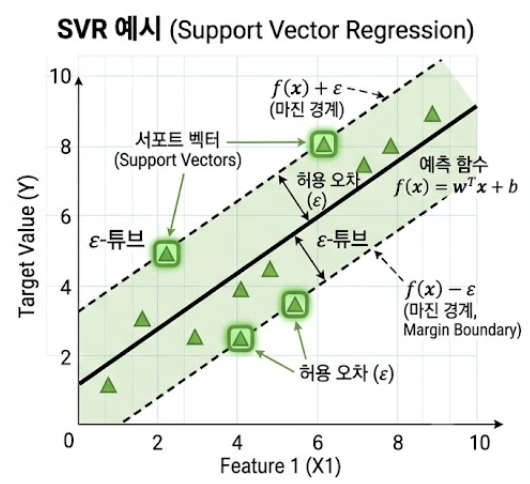

- tube 안쪽 오차: 크게 벌주지 않음
- tube 바깥 오차: C에 따라 벌점 부여


정리하면 SVR은 **모든 점을 정확히 지나가는 곡선**을 찾는 모델이 아님.  
대신 **허용 오차 범위 안에서는 너그럽게 보고, 범위를 벗어난 오차를 줄이는 예측 함수**를 찾는 모델임.

## 02. 실습 환경 준비

- `SVR`: SVM 기반 회귀 모델임.
- `StandardScaler`: feature와 target의 스케일을 맞추는 전처리기임.
- `GridSearchCV`: 여러 하이퍼파라미터 후보를 교차검증으로 비교하는 도구임.
- `R2`, `MAE`, `RMSE`: 회귀 모델 성능을 확인하는 대표 지표임.
- `Path`: 노트북 실행 위치가 달라도 로컬 CSV 경로를 안정적으로 찾기 위해 사용함.



In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

## 03. 예제용 비선형 데이터 생성

- SVR의 kernel 차이를 직관적으로 보기 위해 사인 곡선 형태의 샘플 데이터를 만듦.
- 실제 데이터가 아니라 예측 곡선과 epsilon tube를 설명하기 위한 수업용 데이터임.
- 일부 노이즈를 추가해 실제 데이터처럼 예측선에서 벗어난 점이 생기도록 함.



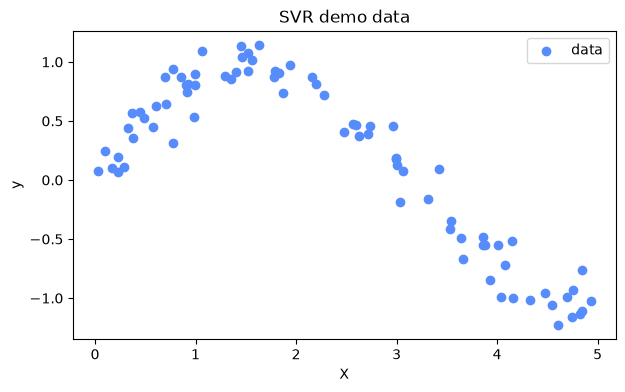

In [2]:
np.random.seed(42)

# np.random.rand(): 0~1 사이 난수를 생성함.
# 5를 곱해 X 범위를 0~5 사이로 확장함.
svr_demo_X = np.sort(5 * np.random.rand(80, 1), axis=0)

# np.sin(): 비선형 패턴을 만들기 위해 사인 함수를 적용함.
# randn()으로 작은 노이즈를 추가해 실제 데이터처럼 완벽하지 않게 만듦.
svr_demo_y = np.sin(svr_demo_X).ravel() + 0.15 * np.random.randn(80)

plt.figure(figsize=(7, 4))
plt.scatter(svr_demo_X, svr_demo_y, label='data')
plt.xlabel('X')
plt.ylabel('y')
plt.title('SVR demo data')
plt.legend()
plt.show()


## 04. epsilon tube와 support vector 시각화

- SVR은 예측 함수 주변에 `epsilon` 폭의 tube를 만든다고 생각하면 이해하기 쉬움.
- tube 안쪽 오차는 크게 문제 삼지 않음.
- tube 밖에 있거나 tube 경계에 걸리는 데이터는 모델 학습에 더 중요하게 작용할 수 있음.
- 이 중요한 데이터들이 SVR에서의 support vector임.



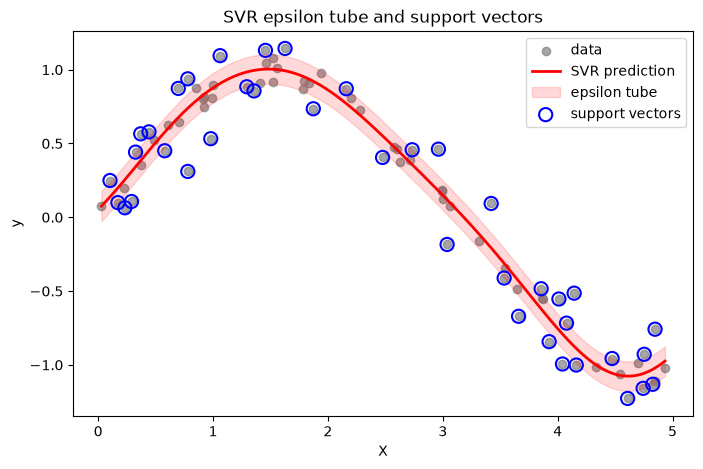

서포트 백터 개수: 39


In [10]:
epsilon_value = 0.1

svr_tube_model = SVR(kernel='rbf',
                     C=10,  # epsilon tube를 벗어난 예측에 대한 벌점
                     gamma=0.7, # rbf 커널에서 하나의 데이터 포인트가 주변에 영향을 미치는 범위
                     epsilon=epsilon_value) # 회귀 함수(예측 함수) 주변 오차 허용 범위

svr_tube_model.fit(svr_demo_X, svr_demo_y)

x_line = np.linspace(
    svr_demo_X.min(),
    svr_demo_X.max(),
    300
).reshape(-1 ,1)

y_line = svr_tube_model.predict(x_line)

plt.figure(figsize=(8, 5))
plt.scatter(svr_demo_X, svr_demo_y, color='gray', alpha=0.7, label='data')
plt.plot(x_line, y_line, color='red', linewidth=2, label='SVR prediction')

# fill_between(): 예측 함수 위아래로 epsilon만큼 허용 오차 범위를 표시함.
plt.fill_between(
    x_line.ravel(),
    y_line - epsilon_value,
    y_line + epsilon_value,
    color='red',
    alpha=0.15,
    label='epsilon tube'
)

# support_: 학습 데이터 중 support vector로 선택된 샘플의 위치 인덱스임.
plt.scatter(
    svr_demo_X[svr_tube_model.support_],
    svr_demo_y[svr_tube_model.support_],
    facecolors='none',
    edgecolors='blue',
    s=90,
    linewidths=1.5,
    label='support vectors'
)

plt.xlabel('X')
plt.ylabel('y')
plt.title('SVR epsilon tube and support vectors')
plt.legend()

plt.show()

print("서포트 백터 개수:", len(svr_tube_model.support_))

## 05. Kernel별 SVR 예측 곡선 비교

- `linear` kernel은 직선에 가까운 예측을 만듦.
- `poly` kernel은 다항식 형태의 곡선을 만들 수 있음.
- `rbf` kernel은 부드러운 비선형 곡선을 만들 수 있음.
- 같은 데이터라도 kernel을 바꾸면 모델이 표현할 수 있는 예측 함수의 모양이 달라짐.



linear: 0.6238236989298106
poly: 0.8219592609069226
rbf: 0.9614710580001831


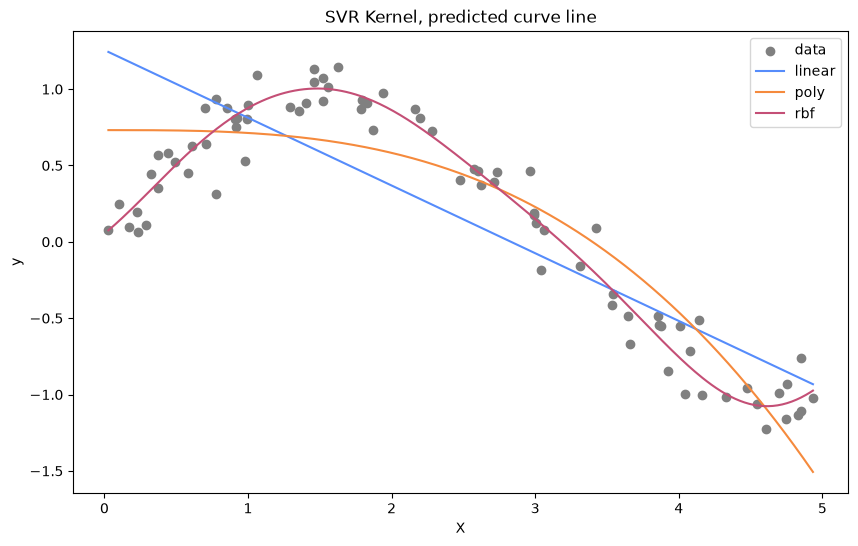

In [18]:
x_line = np.linspace(
    svr_demo_X.min(),
    svr_demo_X.max(),
    300
).reshape(-1 ,1)

svr_demo_models = {
    'linear': SVR(kernel='linear', C=10, epsilon=0.1),
    'poly' : SVR(kernel='poly', C=10, degree=3, epsilon=0.1),
    'rbf': SVR(kernel='rbf', C=10, gamma=0.7, epsilon=0.1),
}

plt.figure(figsize=(10, 6))
plt.scatter(svr_demo_X, svr_demo_y, label='data', color='gray')

for name, model in svr_demo_models.items(): # items(): dict에서 하나의 key-value를 묶은 것
    model.fit(svr_demo_X, svr_demo_y)
    y_line = model.predict(x_line)
    plt.plot(x_line, y_line, label=name)
    print(f"{name}:", model.score(svr_demo_X, svr_demo_y))

plt.xlabel('X')
plt.ylabel('y')
plt.title("SVR Kernel, predicted curve line")
plt.legend()
plt.show()

## 06. California Housing 데이터 로드

- California Housing 데이터는 지역별 주택 가격을 예측하는 회귀 데이터임.
- `MedHouseVal`은 target이고 나머지 컬럼은 feature임.
- `fetch_california_housing()`은 환경에 따라 403 오류가 발생할 수 있어 로컬 CSV를 사용함.
- SVR은 큰 데이터에서 학습 시간이 길어질 수 있어 수업에서는 일부 샘플을 사용함.



In [19]:
# 노트북 실행 위치가 단원 폴더일 때와 저장소 루트일 때를 모두 고려함.
data_candidates = [
    Path('data/california_housing.csv'),
    Path('05_machine_learning/01_shared/04_decision_tree_svm/data/california_housing.csv')
]

housing_data_path = next((path for path in data_candidates if path.exists()), None)
if housing_data_path is None:
    raise FileNotFoundError('california_housing.csv 파일을 찾을 수 없습니다.')

housing_df = pd.read_csv(housing_data_path)

# sample(): SVR 수업 실습 속도를 위해 일부 데이터만 무작위로 추출함.
housing_sample_df = housing_df.sample(n=3000, random_state=42)

housing_feature_names = housing_sample_df.drop(columns='MedHouseVal').columns.tolist()
housing_X = housing_sample_df[housing_feature_names]
housing_y = housing_sample_df['MedHouseVal']

display(housing_sample_df.head())
print('데이터 경로:', housing_data_path)
print('전체 데이터 크기:', housing_df.shape)
print('수업용 샘플 크기:', housing_sample_df.shape)
print('feature 개수:', len(housing_feature_names))


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
20046,1.6812,25.0,4.192201,1.022284,1392.0,3.877437,36.06,-119.01,0.47700
3024,2.5313,30.0,5.039384,1.193493,1565.0,2.679795,35.14,-119.46,0.45800
15663,3.4801,52.0,3.977155,1.185877,1310.0,1.360332,37.80,-122.44,5.00001
20484,5.7376,17.0,6.163636,1.020202,1705.0,3.444444,34.28,-118.72,2.18600
9814,3.7250,34.0,5.492991,1.028037,1063.0,2.483645,36.62,-121.93,2.78000


데이터 경로: data\california_housing.csv
전체 데이터 크기: (20640, 9)
수업용 샘플 크기: (3000, 9)
feature 개수: 8


## 07. 학습/평가 데이터 분리와 스케일링

- SVR은 feature 스케일에 민감하므로 `StandardScaler`를 사용함.
- SVR의 `epsilon`과 `C`는 target 값의 크기에도 영향을 받을 수 있음.
- 여기서는 `y`도 함께 스케일링해 SVR이 안정적으로 학습되도록 함.
- 평가 결과를 사람이 읽기 쉽게 만들기 위해 예측값은 다시 원래 target 단위로 복원함.



In [36]:
housing_X_train, housing_X_test, housing_y_train, housing_y_test = train_test_split(
    housing_X,
    housing_y,
    test_size=0.2,
    random_state=42
)

housing_X_scaler = StandardScaler()
housing_X_train_scaled = housing_X_scaler.fit_transform(housing_X_train)
housing_X_test_scaled = housing_X_scaler.transform(housing_X_test)

# y 정답 데이터도 스케일링
housing_y_scaler = StandardScaler()

# y 정답 데이터 (1차원) -> 2차원으로 변경하여 스케일링 -> 1차원 변경
housing_y_train_scaled = housing_y_scaler.fit_transform(housing_y_train.to_numpy().reshape(-1, 1)).ravel()

housing_y_test_scaled = housing_y_scaler.transform(housing_y_test.to_numpy().reshape(-1, 1)).ravel()


print('학습 데이터:', housing_X_train.shape, housing_y_train.shape)
print('평가 데이터:', housing_X_test.shape, housing_y_test.shape)
print('스케일링 전 X 예시:', housing_X_train.iloc[0].round(3).to_dict())
print('스케일링 후 X 예시:', np.round(housing_X_train_scaled[0], 3))
print('스케일링 전 y 예시:', round(housing_y_train.iloc[0], 3))
print('스케일링 후 y 예시:', round(housing_y_train_scaled[0], 3))

학습 데이터: (2400, 8) (2400,)
평가 데이터: (600, 8) (600,)
스케일링 전 X 예시: {'MedInc': 4.364, 'HouseAge': 33.0, 'AveRooms': 5.51, 'AveBedrms': 1.015, 'Population': 1869.0, 'AveOccup': 3.468, 'Latitude': 33.81, 'Longitude': -118.0}
스케일링 후 X 예시: [ 0.274  0.332  0.056 -0.211  0.429  0.221 -0.833  0.769]
스케일링 전 y 예시: 2.018
스케일링 후 y 예시: -0.045


 ## 08. Kernel별 SVR 모델 학습과 평가

- 회귀 모델 평가는 `R2`, `MAE`, `RMSE`를 함께 확인함.
- `R2`는 높을수록 좋고, `MAE`, `RMSE`는 낮을수록 좋음.
- SVR은 kernel과 하이퍼파라미터에 따라 성능 차이가 크게 날 수 있음.
- 예측값은 스케일링된 값으로 나오므로, 평가 전 원래 target 단위로 복원해야 함.



In [37]:
# gamma = 'scale'   <- 사이킷런에서 제공하는 감마 옵션
# gamma = 1 / (n_features * X.var())
# 데이터 크기에 맞춰서 알아서 계산

svr_models = {
    'linear' : SVR(kernel='linear', C=1, epsilon=0.1),
    'poly' : SVR(kernel='poly', C=10, degree=2, epsilon=0.1),
    'rbf': SVR(kernel='rbf', C=10, gamma='scale', epsilon=0.1),
}

svr_results = []    # 각 모델의 평가 지표를 저장할 list
trained_svr_models = {}     # 학습된 모델을 저장할 dict

for name, model in svr_models.items():
    model.fit(housing_X_train_scaled, housing_y_train_scaled)
    trained_svr_models[name] = model

    pred_scaled = model.predict(housing_X_test_scaled)

    # inverse_transform(): 예측값을 원래 MedHouseVal 단위로 복원함.
    pred = housing_y_scaler.inverse_transform(pred_scaled.reshape(-1, 1)).ravel()

    svr_results.append({
        'kernel': name,
        'R2': r2_score(housing_y_test, pred),
        'MAE': mean_absolute_error(housing_y_test, pred),
        'RMSE': root_mean_squared_error(housing_y_test, pred),
        'MSE': mean_squared_error(housing_y_test, pred),
        'support_vector_count': len(model.support_)
    })

svr_results_df = pd.DataFrame(svr_results)
display(svr_results_df)

# RMSE가 가장 낮은 커널을 사용한 모델 선택
best_svr_model = trained_svr_models['rbf']

,kernel,R2,MAE,RMSE,MSE,support_vector_count
0,linear,0.644498,0.490166,0.680904,0.463630,1959
1,poly,0.179622,0.773677,1.034360,1.069901,2090
2,rbf,0.741351,0.406102,0.580791,0.337318,1843


## 09. 새로운 샘플 예측 결과 확인

- 회귀 모델은 새 feature 조합을 넣으면 연속형 숫자 target을 예측함.
- 여기서는 평가 데이터 일부를 새 데이터처럼 사용해 실제값과 예측값을 비교함.
- 스케일링된 예측값은 반드시 원래 target 단위로 복원해야 해석 가능함.
- `abs_error`는 실제값과 예측값이 얼마나 차이 나는지 보여주는 절대 오차임.



In [38]:
sample_X = housing_X_test.iloc[:5]
sample_X_scaled = housing_X_scaler.transform(sample_X)

sample_pred_scaled = best_svr_model.predict(sample_X_scaled)
sample_pred = housing_y_scaler.inverse_transform(sample_pred_scaled.reshape(-1, 1)).ravel()

prediction_df = sample_X.copy()
prediction_df['actual_MedHouseVal'] = housing_y_test.iloc[:5].to_numpy()
prediction_df['pred_MedHouseVal'] = sample_pred
prediction_df['abs_error'] = np.abs(prediction_df['actual_MedHouseVal'] - prediction_df['pred_MedHouseVal'])

display(prediction_df[['MedInc', 'HouseAge', 'AveRooms', 'actual_MedHouseVal', 'pred_MedHouseVal', 'abs_error']].round(3))

,MedInc,HouseAge,AveRooms,actual_MedHouseVal,pred_MedHouseVal,abs_error
5182,1.633,37.0,3.670,0.945,1.143,0.198
6769,3.948,52.0,5.440,4.191,2.511,1.680
15066,1.989,19.0,4.083,1.125,1.195,0.070
19296,3.885,40.0,5.648,2.159,2.328,0.169
19246,2.065,14.0,3.491,1.354,1.688,0.334


## 10. GridSearchCV로 RBF SVR 튜닝

- `GridSearchCV`는 여러 하이퍼파라미터 후보를 교차검증으로 비교함.
- SVR은 `C`, `epsilon`, `gamma`에 민감하므로 후보를 작게 잡아 먼저 비교함.
- scikit-learn의 `neg_mean_squared_error`는 점수가 클수록 좋다는 규칙 때문에 음수 MSE로 반환됨.
- 수업 환경에서 병렬 처리 문제가 생기지 않도록 `n_jobs=1`로 실행함.



In [40]:
param_grid = {
    'C': [1, 10],
    'epsilon': [0.05, 0.1],
    'gamma': ['scale', 0.1] # scale: 자동계산
}

rbf_svr = SVR(kernel='rbf')

# GridSearchCV(): 후보 조합을 교차검증으로 비교함.
# cv=3: 학습 데이터를 3개 fold로 나누어 검증함.
# scoring='neg_mean_squared_error': MSE에 -1을 곱한 점수로 비교함.
# n_jobs=1: 수업 환경에서 병렬 처리 관련 문제를 피하기 위해 단일 작업으로 실행함.
svr_grid_search = GridSearchCV(
    rbf_svr,
    param_grid=param_grid,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=1
)

svr_grid_search.fit(housing_X_train_scaled, housing_y_train_scaled)

best_cv_mse_scaled = -svr_grid_search.best_score_
print('best_params:', svr_grid_search.best_params_)
print('best_cv_MSE_scaled:', best_cv_mse_scaled)
print('best_cv_RMSE_scaled:', np.sqrt(best_cv_mse_scaled))

best_params: {'C': 10, 'epsilon': 0.1, 'gamma': 'scale'}
best_cv_MSE_scaled: 0.2651057378604896
best_cv_RMSE_scaled: 0.5148841984956322


## 11. 튜닝 모델 최종 평가

- 교차검증으로 고른 모델도 마지막에는 따로 둔 평가셋에서 다시 확인해야 함.
- 평가셋 성능은 원래 target 단위로 복원한 예측값으로 계산함.
- 튜닝 결과가 항상 크게 좋아지는 것은 아니며, 후보 범위와 데이터 특성에 따라 결과가 달라질 수 있음.



In [42]:
# 제일 좋은 평가를 받은 하이퍼 파라미터가 적용된 모델을 반환 받기
best_tuned_svr = svr_grid_search.best_estimator_

tuned_pred_scaled = best_tuned_svr.predict(housing_X_test_scaled)

tuned_pred = housing_y_scaler.inverse_transform(
    tuned_pred_scaled.reshape(-1, 1)
).ravel()   # ravel(): 2차원 -> 1차원

print("튜닝모델 R2:", r2_score(housing_y_test, tuned_pred))
print("튜닝모델 MA:", mean_absolute_error(housing_y_test, tuned_pred))
print("튜닝모델 MSE:", mean_squared_error(housing_y_test, tuned_pred))
print("튜닝모델 RMSE:", root_mean_squared_error(housing_y_test, tuned_pred))

튜닝모델 R2: 0.7413512474291035
튜닝모델 MA: 0.40610165098654016
튜닝모델 MSE: 0.3373183228670376
튜닝모델 RMSE: 0.5807911181027458
